In [1]:
import jax
import equinox as eqx
import numpy as np
import jax.numpy as jnp
import immrax as irx
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cvxpy as cp
import scipy
from immutabledict import immutabledict
from reach import *
from functools import partial
import control
from GPR import *
from TVGPR import *
from cyipopt import minimize_ipopt

# Some configurations
jax.config.update("jax_enable_x64", True)

# We wrap the jax.jit function t/o set the backend to cpu by default for convenience.
device = 'cpu'
def jit (*args, **kwargs):
    kwargs.setdefault('backend', device)
    return jax.jit(*args, **kwargs)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 14
})

np.random.seed(0)

In [2]:
# system dynamics and initial conditions

class PlanarMultirotor (irx.System) :
    def __init__ (self) :
        self.xlen = 5
        self.evolution = 'continuous'

    ## TRANSFORMED DYNAMICS
    # def f(self, t, x, u, w):
    #     px, py, h, v, theta = x.ravel()
    #     # u1, u2 = u.ravel()
    #     u1 = u[0]
    #     u2 = u[1]
    #     w1 = w[0]
    #     g = 9.81

    #     return jnp.array([
    #         h*jnp.cos(theta) - v*jnp.sin(theta),
    #         h*jnp.sin(theta) + v*jnp.cos(theta),
    #         -g*jnp.sin(theta) + w1*jnp.cos(theta),
    #         u1 - g*jnp.cos(theta) - w1*jnp.sin(theta),
    #         u2
    #     ])
    
    # def f_np(self, t, x, u, w):
    #     px, py, h, v, theta = x.ravel()
    #     u1 = u[0]
    #     u2 = u[1]
    #     w1 = w[0]
    #     g = 9.81

    #     return np.array([
    #         h*np.cos(theta) - v*np.sin(theta),
    #         h*np.sin(theta) + v*np.cos(theta),
    #         -g*np.sin(theta) + w1*np.cos(theta),
    #         u1 - g*np.cos(theta) - w1*np.sin(theta),
    #         u2
    #     ])
    
    ## ORIGINAL DYNAMICS
    def f(self, t, x, u, w):
        px, py, vx, vy, theta = x.ravel()
        # u1, u2 = u.ravel()
        u1 = u[0]
        u2 = u[1]
        w1 = w[0]
        g = 9.81

        return jnp.array([
            vx,
            vy,
            -1*u1*jnp.sin(theta) + w1,
            u1*jnp.cos(theta) - g,
            u2
        ])
    
    def f_np(self, t, x, u, w):
        px, py, vx, vy, theta = x.ravel()
        u1 = u[0]
        u2 = u[1]
        w1 = w[0]
        g = 9.81

        return np.array([
            vx,
            vy,
            -1*u1*np.sin(theta) + w1,
            u1*np.cos(theta) - g,
            u2
        ])

sys = PlanarMultirotor()

# initial conditions
x0 = jnp.array([-4., 8., 0., 0., 0.1])
u0 = jnp.array([9.81, 0.0])

w0 = jnp.array([0.0])

# x0_buf = 0.05 * jnp.array([1.0, 1.0, 1.0, 1.0, 1.0])
x0_buf = jnp.array([0.01, 0.01, 0.01, 0.01, 0.01])
ix0 = irx.icentpert(x0, x0_buf)
print(ix0)

ulim = irx.interval([-1, -1.],[1, 1.])*10 + u0

former_disturbance_GP = GPR(jnp.array([[-2,-0.66005468347438],
                                       [0,1.71910828159421],
                                       [2,-2.73909534657961],
                                       [4,3.76474225408493],
                                       [6,3.65733558594356],
                                       [8,-0.116994810217270],
                                       [10,2.40224375111040],
                                       [12,-2.86490929098228]]), 
                                       sigma_f = 5.0, 
                                       l=2.0, 
                                       sigma_n = 0.01)
actual_disturbance_GP = TVGPR(jnp.array([[0, -2,-0.66005468347438],
                                       [0, 0,1.71910828159421],
                                       [0, 2,-2.73909534657961],
                                       [0, 4,3.76474225408493],
                                       [0, 6,3.65733558594356],
                                       [0, 8,-0.116994810217270],
                                       [0, 10,2.40224375111040],
                                       [0, 12,-2.86490929098228],
                                    #    [16, -2,2.80494480741922],
                                    #    [16, 0,-1.65967058757266],
                                    #    [16, 2,-2.21529178685802],
                                    #    [16, 4,-2.41828274757721],
                                    #    [16, 6,-0.976879063072681],
                                    #    [16, 8,-2.89172701466510],
                                    #    [16, 10,-3.91337304908981],
                                    #    [16, 12,-3.33944976072828],
                                       ]), 
                                       sigma_f = 5.0, 
                                       l=2.0, 
                                       sigma_n = 0.01,
                                       epsilon=0.1,
                                       discrete=False
                                       )


def actual_disturbance_test (t, x, epsilon=0.1) :
    return actual_disturbance_GP.mean(jnp.array([t, x[1]])).reshape(-1)

#sanity check: these should be the same if TVGPR discrete = false
print(actual_disturbance_test(0.0, x0))
print(former_disturbance_GP.mean(jnp.array([x0[1]])).reshape(-1))

# GP = GPR(jnp.array([[1., 1.], [2., 1.0], [0., 1.]]), sigma_f = 1.0, l=2.0, sigma_n = 0.01)

# GP = GPR(jnp.array([[0.0, 1.], [1.0, 1.0], [-1.0, 0.5], [2.0, 1.0]]))
# GP = GPR(jnp.array([[0.0, 1.], [1.0, 1.0], [-1.0, 0.5], [0.5, 1.], [0.75, 0.5], [0.25, 1.]]), l=1.)

# DEBUGGING GP
# print(GP.x)
# print(GP.y)
# # print(np.sqrt(GP.variance(jnp.array([x0[1]])).reshape(-1)))
# def sigma(t, x):
#     return jnp.sqrt(GP.variance(jnp.array([x[1]])).reshape(-1))

# @jit
# def sigma_bruteforce_if(t, ix):
#     div = 100
#     x_list = [ix.lower + ((ix.upper - ix.lower)/div)*i for i in range(div)]
#     sigma_list = 3.0*jnp.array([sigma(t, x) for x in x_list])
#     return irx.interval(jnp.array([jnp.min(sigma_list)]), jnp.array([jnp.max(sigma_list)]))

# print(sigma(0.0, ix0.lower)) 
# print(sigma(0.0, ix0.upper)) 
# # for i in range(100):
#     # print(sigma(0.0, ix0.lower + ((ix0.upper - ix0.lower)/100)*i))
# # sigma_list = [sigma(0.0, ix0.lower + ((ix0.upper - ix0.lower)/1000)*i) for i in range(1000)]
# # print(np.min(sigma_list), np.max(sigma_list))
# print(sigma_bruteforce_if(0.0, ix0))
# # print(irx.natif(sigma)(0.0, ix0))

# sigma_if = lambda t, x : irx.icentpert(0.0, irx.natif(sigma)(t, x).upper)
# print(sigma_if(0.0, ix0))


[[(-4.01, -3.99)]
 [( 7.99,  8.01)]
 [(-0.01,  0.01)]
 [(-0.01,  0.01)]
 [( 0.09,  0.11)]]
[-0.11677686]
[-0.11677686]


In [3]:
obs = jnp.array([[0, x0[1], actual_disturbance_test(0.0, x0)[0]], 
                    [0, x0[1], actual_disturbance_test(0.0, x0)[0]], 
                    [0, x0[1], actual_disturbance_test(0.0, x0)[0]],
                    [0, x0[1], actual_disturbance_test(0.0, x0)[0]],
                    [0, x0[1], actual_disturbance_test(0.0, x0)[0]],
                    [0, x0[1], actual_disturbance_test(0.0, x0)[0]],
                    [0, x0[1], actual_disturbance_test(0.0, x0)[0]],
                    [0, x0[1], actual_disturbance_test(0.0, x0)[0]],
                    [0, x0[1], actual_disturbance_test(0.0, x0)[0]]])

# obs = jnp.array([[0.,         6. ,        3.65728629],
#  [0.   ,      6.     ,    3.65728629],
#  [0.    ,     6.    ,     3.65728629],
#  [0.     ,    6.   ,      3.65728629],
#  [0.      ,   6.  ,       3.65728629],
#  [0.       ,  6. ,        3.65728629],
#  [0.36      , 5.57207151 ,4.76719219]])

testGPR = TVGPR(obs)
print('ts', testGPR.ts)
print(testGPR.mean(jnp.hstack((10.0, x0[1]))).reshape(-1))
def test_disturbance(t, x):
    return testGPR.mean(jnp.hstack((t, x[1]))).reshape(-1)
print(test_disturbance(0, x0))
test_mjacM = irx.mjacM(test_disturbance)
test_perm = irx.Permutation((0, 1, 2, 4, 5, 3))
t_int = irx.interval([10.0])
print(t_int)
print(ix0)
print("begin TEST_MG")
TEST_MG = test_mjacM(irx.interval(jnp.array([0.])), ix0, 
                         centers=((jnp.array([0.]), x0,),), 
                         permutations=(test_perm,))
print(TEST_MG)

ts [0. 0. 0. 0. 0. 0. 0. 0. 0.]
[-0.06895557]
[-0.11677686]
[[(10., 10.)]]
[[(-4.01, -3.99)]
 [( 7.99,  8.01)]
 [(-0.01,  0.01)]
 [(-0.01,  0.01)]
 [( 0.09,  0.11)]]
begin TEST_MG
[[[[0.00615184]] <= x <= [[0.00615184]], [[ 0.         -0.00116777  0.          0.          0.        ]] <= x <= [[0.         0.00116777 0.         0.         0.        ]]]]


In [4]:
print(jnp.hstack((jnp.array([0.]), x0[1])))
print(testGPR.ts)
print(testGPR.mean(jnp.hstack((jnp.array([0.]), x0[1]))).shape)
test = lambda t, x : jnp.hstack((testGPR.mean(jnp.hstack((t, x[1]))), 0.))
# print(jax.jacfwd(test, argnums=1)(jnp.array([0.]), x0))
# print(ix0.upper.shape)
# print(irx.natif(test)(irx.interval([0.]), ix0))
get_dt = lambda x : jax.vmap(lambda i: jnp.power((1-.1), ((x[0] - i)/2)))(testGPR.ts)
# print(irx.natif())
print(jax.make_jaxpr(get_dt)((jnp.hstack((jnp.array([0.]), x0[1])))))
print(get_dt(jnp.hstack((jnp.array([0.]), x0[1]))))
print(irx.natif(get_dt)(irx.interval(jnp.hstack((jnp.array([0.]), x0[1])))))

[0. 8.]
[0. 0. 0. 0. 0. 0. 0. 0. 0.]
(1,)
{ lambda a:f64[9]; b:f64[2]. let
    c:f64[1] = slice[limit_indices=(1,) start_indices=(0,) strides=None] b
    d:f64[] = squeeze[dimensions=(0,)] c
    e:f64[9] = sub d a
    f:f64[9] = div e 2.0:f64[]
    g:f64[9] = pow 0.9:f64[] f
  in (g,) }
[1. 1. 1. 1. 1. 1. 1. 1. 1.]
[[(1., 1.)]
 [(1., 1.)]
 [(1., 1.)]
 [(1., 1.)]
 [(1., 1.)]
 [(1., 1.)]
 [(1., 1.)]
 [(1., 1.)]
 [(1., 1.)]]


def mean_disturbance (t, x) :
    return GP.mean(jnp.array([x[1]])).reshape(-1)
    # return GP.mean(x[(0,),])
print(ix0[(0,),])
print(x0[0])

def tr (x) :
    # return x[(0,),]
    return jnp.array([x[0]])

# print(tr(ix0))
print(irx.natif(tr)(ix0))
print(mean_disturbance(0.0, x0))
print(sigma_bruteforce_if(0.0, ix0))

In [5]:
# determinant helper function, can't use np.linalg.det because it uses a primitive not in immrax
def getDet(mat, n=5):
  
    # Base case: if the matrix is 1x1
    if n == 1:
        return mat[0][0]
    
    # Base case for 2x2 matrix
    if n == 2:
        return mat[0][0] * mat[1][1] - \
               mat[0][1] * mat[1][0]
    
    # Recursive case for larger matrices
    res = 0
    for col in range(n):
      
        # Create a submatrix by removing the first 
        # row and the current column
        sub = [[0] * (n - 1) for _ in range(n - 1)]
        for i in range(1, n):
            subcol = 0
            for j in range(n):
              
                # Skip the current column
                if j == col:
                    continue
                
                # Fill the submatrix
                sub[i - 1][subcol] = mat[i][j]
                subcol += 1
        
        # Cofactor expansion
        sign = 1 if col % 2 == 0 else -1
        res += sign * mat[0][col] * getDet(sub, n - 1)
    
    return res

In [6]:
# Get initial P, K from LQR

# linearize system around x0, u0
A, B = jax.jacfwd(lambda x: sys.f(0, x, u0, [0]))(x0), jax.jacfwd(lambda u: sys.f(0, x0, u, [0]))(u0)
# print(A)
# print(B)

Alin = A 
Blin = B

# weight matrices
Q = jnp.array([1, 1, 1, 1, 1]) * jnp.eye(sys.xlen)
R = jnp.array([1, 1]) * jnp.eye(2)

# LQR to get initial K, P
K, P, _ = control.lqr(A, B, Q, R)
feedback_K = -1 * K
print(feedback_K)

# A, B = jax.jacfwd(lambda x: sys.f(0, x, u0, [0]))(x0*0.0), jax.jacfwd(lambda u: sys.f(0, x0, u, [0]))(u0)
A = jnp.array([[0, 0, 1, 0, 0], 
               [0, 0, 0, 1, 0], 
               [0, 0, 0, 0, -9.81], 
               [0, 0, 0, 0, 0], 
               [0, 0, 0, 0, 0]])
B = jnp.array([[0, 0], 
               [0, 0], 
               [0, 0], 
               [1, 0], 
               [0, 1]])
Q = jnp.array([1000, 20, 500, 500, 1]) * jnp.eye(sys.xlen)
R = jnp.array([20, 20]) * jnp.eye(2)
K, P, _ = control.lqr(A, B, Q, R)
backup_K = -1 * K
print(backup_K)


[[ 9.98334166e-02 -9.95004165e-01  1.72916550e-01 -1.72339777e+00
  -1.25670810e-15]
 [ 9.95004165e-01  9.98334166e-02  1.44427207e+00  1.44910564e-01
  -5.42944692e+00]]
[[-1.56059891e-15 -1.00000000e+00  1.33795215e-17 -5.19615242e+00
  -1.79476449e-16]
 [ 7.07106781e+00 -6.05661594e-16  6.41708330e+00 -1.79476449e-16
  -1.12228862e+01]]


In [7]:
# Simulation parameters
t0 = 0.     # Initial time
dt = 0.01  # Time step

T_initial = 0.2   # Horizon for initial rollout (0.05 works)
T = 10.0   # Horizon for closed-loop rollout
tt = np.arange(t0, T+dt, dt)
# print(tt)
# T = 0.1
# N = 5       # Number of iterations of the algorithm
# tf = T*N    # Final time

sys_mjacM = irx.mjacM(sys.f)
sys_jacM = irx.jacM(sys.f)

perm = irx.Permutation((0, 1, 2, 3, 4, 5, 6, 7, 8))

# G_mjacM = irx.mjacM(mean_disturbance)
# G_jacM = irx.jacM(mean_disturbance)
# G_perm = irx.Permutation((0, 1, 3, 4, 5, 2))

# sigma_mjacM = irx.mjacM(sigma)


# print(sigma(0.0, x0)) 

# sigma_if = lambda t, x : irx.icentpert(0.0, irx.natif(sigma)(t, x).upper)

# print(sigma_if(0.0, ix0))

# def upper_bound(t, x):
#     return GP.mean(jnp.array([x[1]])).reshape(-1) + sigma(t, x)#jnp.sqrt(GP.variance(jnp.array([x[1]])).reshape(-1))

# def lower_bound(t, x):
#     return GP.mean(jnp.array([x[1]])).reshape(-1) - sigma(t, x)#jnp.sqrt(GP.variance(jnp.array([x[1]])).reshape(-1))

# dist_if = lambda t, x : irx.interval(irx.natif(lower_bound)(t, x).lower, irx.natif(upper_bound)(t, x).upper)  
# test_interval = irx.icentpert(x0, jnp.array([1, 1, 1, 1, 1]))
# print(dist_if(0.0, test_interval))
# print(mean_disturbance(0.0, x0))
# print(dist_if(0.0, test_interval) - mean_disturbance(0.0, x0))

In [8]:

@partial(jit, static_argnames=('mjacM',))
def rollout (t_init, ix, xc, K_feed, K_backup, obs, mjacM=True) :
    # mjacM=True
    def mean_disturbance (t, x) :
            return GP.mean(jnp.hstack((t, x[1]))).reshape(-1)    

    def sigma_squared(t, x):
        return GP.variance(jnp.hstack((t, x[1]))).reshape(-1)
        # return jnp.sqrt(GP.variance(jnp.hstack((t, x[1]))).reshape(-1))

    def sigma_bruteforce_if(t, ix):
        div = 100
        x_list = ix.lower + ((ix.upper - ix.lower))*jnp.linspace(0., 1., div).reshape(-1, 1)
        sigma_list = 9.0*jnp.array([sigma_squared(t, x) for x in x_list])
        return irx.interval(jnp.array([jnp.min(sigma_list)]), jnp.array([jnp.max(sigma_list)]))
        
    def step (carry, t) :
        xtut, xnomt, M, uM, wM, G, sig_range, MS, it = carry
        # uint = irx.icentpert(unomt, 1)
        # unomt = jnp.array([9.0 + 0.1*t, 0.1])
        ubackup = (K_backup @ xnomt) + jnp.array([9.81, 0.0])
        buffer_thr = 5
        buffer_ang = 5
        unomt = jnp.array([jnp.minimum(jnp.maximum(ubackup[0], ulim.lower[0] + buffer_thr), ulim.upper[0] - buffer_thr),
            jnp.minimum(jnp.maximum(ubackup[1], ulim.lower[1] + buffer_ang), ulim.upper[1] - buffer_ang)])
        # print(unomt)

        # test values
        # wnomt = jnp.array([0.0])
        # wint = irx.icentpert(wnomt, jnp.array([1.]))
        
        wnomt = GP.mean(jnp.array([t, xnomt[1]])).reshape(-1)
        # sigma_int = irx.icentpert(0.0, sigma(t, xnomt))
        # wint = irx.interval(wnomt) + sigma_if(t, irx.ut2i(xtut))
        # wint = dist_if(t, irx.ut2i(xtut))
        # w_diff = wint - wnomt


        MS = sigma_jacM(irx.interval(0.), irx.ut2i(xtut))[1]
        # _, MS = sigma_mjacM(irx.interval(jnp.array([0.])), irx.ut2i(xtut), 
        #                      centers=((jnp.array([0.]), xnomt,),), 
        #                      permutations=(sigma_perm,))[0]

        # buffer sampled sigma bound with lipschitz constant to recover guarantee
        xint = irx.ut2i(xtut)
        x_div = (xint.upper - xint.lower)/(100*2)
        sigma_lip = 9.0 * MS.upper @ x_div.T
        

        # w_diff = sigma_if(t, irx.ut2i(xtut)) 
        w_diff = sigma_bruteforce_if(t, irx.ut2i(xtut))
        sig_upper = jnp.sqrt(w_diff.upper + sigma_lip[1])
        w_diffint = irx.icentpert(0.0, sig_upper)
        wint = irx.interval(wnomt) + w_diffint

        

        if mjacM :
            Mt, Mx, Mu, Mw = sys_mjacM(irx.interval(t), irx.ut2i(xtut), ulim, wint,
                                centers=((jnp.array([t]), xnomt, unomt, wnomt),), 
                                permutations=(perm,))[0]
            _, MG = G_mjacM(irx.interval(jnp.array([t])), irx.ut2i(xtut), 
                         centers=((jnp.array([t]), xnomt,),), 
                         permutations=(G_perm,))[0]
            
            # print(MG)
        else :
            # Mt, Mx = sys_mjacM(irx.interval(0.), irx.ut2i(xtut), 
            #                     centers=((jnp.array([0.]), xnomt),), 
            #                     permutations=(perm,))[0]
            # _Mt, _Mx = sys_jacM(irx.interval(0.), irx.ut2i(xtut))
            Mt, Mx, Mu, Mw = sys_jacM(irx.interval(0.), irx.ut2i(xtut), ulim, wint)
            _, MG = G_jacM(irx.interval(0.), irx.ut2i(xtut))
            # _, MS = sigma_mjacM(irx.interval(0.), irx.ut2i(xtut))

        Mt = irx.interval(Mt)
        Mx = irx.interval(Mx)
        Mu = irx.interval(Mu)
        Mw = irx.interval(Mw)
        # MG = irx.interval(MG)

        # F = lambda t, x, u : (Mx + Mu@K)@(x - xnomt) + Mu@(unomt) + sys.f(0., xnomt, unomt) # not 100% sure about this
        
        # F = lambda t, x, u, w : (Mx + Mu@K)@(x - xnomt) + Mw@(w - wnomt) + sys.f(0., xnomt, unomt, wnomt) # without GP Jac
        
        # With 1st Order Disturbance Interaction
        F = lambda t, x, u, w: (Mx + Mu@K_feed + Mw@MG)@(x - xnomt) + Mw@w_diffint + sys.f(0., xnomt, unomt, wnomt) # with GP Jac

        # Without Disturbance Interaction
        # F = lambda t, x, u, w: (Mx + Mu@K_feed)@(x - xnomt) + Mw@wint + sys.f(0., xnomt, unomt, wnomt) # with GP Jac
        
        # F = irx.natif(sys.f)
        embsys = irx.ifemb(sys, F)
        xnomtp1 = xnomt + dt*sys.f(t, xnomt, unomt, wnomt)
        xtutp1 = xtut + dt*embsys.E(irx.interval(jnp.array([t])), xtut, unomt, wint)

        
        # MG = jax.jacfwd(mean_disturbance, argnums=(1,))(0., xnomt)[0][0]
        return ((xtutp1, xnomtp1, M|Mx, uM|Mu, wM|Mw, G|MG, sig_range|w_diff, MS, it + 1), (xtutp1, xnomtp1, unomt, MS.upper))
    # unomt = jnp.array(u0)
    GP = TVGPR(obs, sigma_f = 5.0, l=2.0, sigma_n = 0.01, epsilon = 0.25)
    # GP = GPR(obs[:, 1:], sigma_f = 5.0, l=2.0, sigma_n = 0.01)
    tt = jnp.arange(0, T, dt) + t_init
    J0 = jax.jacfwd(sys.f, argnums=(1,))(t_init, xc, u0, w0)[0]
    Ju = jax.jacfwd(sys.f, argnums=(2,))(t_init, xc, u0, w0)[0]
    Jw = jax.jacfwd(sys.f, argnums=(3,))(t_init, xc, u0, w0)[0]
    G0 = jax.jacfwd(mean_disturbance, argnums=(1,))(t_init, xc)[0]
    sig0 = irx.icentpert(0.0, sigma_squared(t_init, xc))
    MS0 = jax.jacfwd(sigma_squared, argnums=(1,))(t_init, xc)[0]
    G_mjacM = irx.mjacM(mean_disturbance)
    G_jacM = irx.jacM(mean_disturbance)
    G_perm = irx.Permutation((0, 1, 2, 4, 5, 3))
    sigma_jacM = irx.jacM(sigma_squared)
    # sigma_mjacM = irx.mjacM(sigma)
    # sigma_perm = irx.Permutation((0, 2, 1, 3, 4, 5))

    carry, xx = jax.lax.scan(step, (irx.i2ut(ix), xc, irx.interval(J0), irx.interval(Ju), irx.interval(Jw), irx.interval(G0), sig0, irx.interval(MS0), 0), tt)
    # return jnp.vstack((irx.i2ut(ix), xx[0])), jnp.vstack((xc, xx[1])), carry[2], carry[3], carry[4], jnp.vstack((u0, xx[2])), carry[5], carry[6]
    return jnp.vstack((irx.i2ut(ix), xx[0])), jnp.vstack((xc, xx[1])), jnp.vstack(xx[2])

# xx, xxnom, M, Mu, Mw, unom_arr, G, sig_range = rollout(ix0, x0, K, u_ref)
xx, xxnom, unom_arr = rollout(0.0, ix0, x0, feedback_K, backup_K, obs)
print(xx.shape)
print(xxnom.shape)
print(unom_arr.shape)

# print(sigma_lip)
print(xx[:10, :])

# print(M.shape)
# print(Mu.shape)
# print(Mw.shape)
# print(unom_arr.shape)
# print(G)
# if np.any(np.isnan(np.array(G.lower))) : raise ValueError("NaN in G")
# print(sig_range)
# print((Mw@G).shape)

(1001, 10)
(1001, 5)
(1000, 2)
[[-4.01000000e+00  7.99000000e+00 -1.00000000e-02 -1.00000000e-02
   9.00000000e-02 -3.99000000e+00  8.01000000e+00  1.00000000e-02
   1.00000000e-02  1.10000000e-01]
 [-4.01010000e+00  7.98990000e+00 -1.68530507e-02 -6.02480672e-02
   4.02745427e-02 -3.98990000e+00  8.01010000e+00  4.91354396e-03
  -4.02325321e-02  5.97254573e-02]
 [-4.01026853e+00  7.98929752e+00 -2.45219758e-02 -1.10293229e-01
  -9.47968412e-03 -3.98985086e+00  8.00969767e+00  5.44229799e-03
  -9.03075954e-02  9.47968412e-03]
 [-4.01051375e+00  7.98819459e+00 -3.12418726e-02 -1.60262933e-01
  -5.93076146e-02 -3.98979644e+00  8.00879460e+00  9.83337199e-03
  -1.40337892e-01 -4.06923854e-02]
 [-4.01082617e+00  7.98659196e+00 -3.67004344e-02 -2.10326406e-01
  -1.09226670e-01 -3.98969811e+00  8.00739122e+00  1.77744552e-02
  -1.90394643e-01 -9.07733296e-02]
 [-4.01119317e+00  7.98448869e+00 -4.07298740e-02 -2.60604814e-01
  -1.59249032e-01 -3.98952036e+00  8.00548727e+00  2.90857393e-02
  

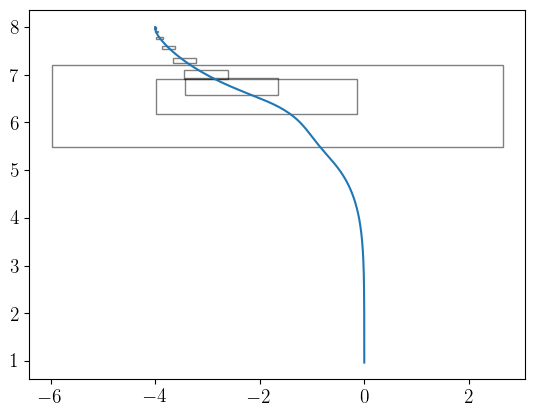

In [9]:

import matplotlib.pyplot as plt

plt.figure()
plt.plot(xxnom[:, 0], xxnom[:, 1], label='x pos nominal')

PLOT_EVERY = 10
PLOT_UNTIL = 100
# plot rectangles to show finv tube
for i in range(0, min(xxnom.shape[0], PLOT_UNTIL), PLOT_EVERY):
    x_center = xxnom[i, 0]
    y_center = xxnom[i, 1]
    width = np.abs(xx[i, 0] - xx[i, 5])
    height = np.abs(xx[i, 1] - xx[i, 6])
    rect = Rectangle((x_center - width/2, y_center - height/2), width, height,
                     linewidth=1, edgecolor='k', facecolor='none', alpha=0.5)
    plt.gca().add_patch(rect)

In [10]:

@partial(jit, static_argnames=('mjacM',))
def rollout_init (t_init, ix, xc, ulimit, K_backup, obs, mjacM=True) :
    # mjacM=True
    def mean_disturbance (t, x) :
            return GP.mean(jnp.hstack((t, x[1]))).reshape(-1)    

    def sigma(t, x):
        return jnp.sqrt(GP.variance(jnp.hstack((t, x[1]))).reshape(-1))

    def sigma_bruteforce_if(t, ix):
        div = 100
        x_list = [ix.lower + ((ix.upper - ix.lower)/div)*i for i in range(div)]
        sigma_list = 3.0*jnp.array([sigma(t, x) for x in x_list])
        return irx.interval(jnp.array([jnp.min(sigma_list)]), jnp.array([jnp.max(sigma_list)]))
    
    def disturbance_bounds_bruteforce(t, ix):
        div = 100
        x_list = [ix.lower + ((ix.upper - ix.lower)/div)*i for i in range(div)]
        mean_list = jnp.array([mean_disturbance(t, x) for x in x_list])
        sigma_list = 3.0*jnp.array([sigma(t, x) for x in x_list])
        return irx.interval(jnp.array([jnp.min(mean_list - sigma_list)]), jnp.array([jnp.max(mean_list + sigma_list)]))
        
    def step (carry, t) :
        xtut, xnomt, M, uM, wM, G, sig_range, MS, it = carry
        # uint = irx.icentpert(unomt, 1)
        # unomt = jnp.array([9.0 + 0.1*t, 0.1])
        ubackup = (K_backup @ xnomt) + jnp.array([9.81, 0.0])
        buffer_thr = 5
        buffer_ang = 5
        unomt = jnp.array([jnp.minimum(jnp.maximum(ubackup[0], ulim.lower[0] + buffer_thr), ulim.upper[0] - buffer_thr),
            jnp.minimum(jnp.maximum(ubackup[1], ulim.lower[1] + buffer_ang), ulim.upper[1] - buffer_ang)])
        # print(unomt)

        # test values
        # wnomt = jnp.array([0.0])
        # wint = irx.icentpert(wnomt, jnp.array([1.]))
        
        wnomt = GP.mean(jnp.array([t, xnomt[1]])).reshape(-1)
        # sigma_int = irx.icentpert(0.0, sigma(t, xnomt))
        # wint = irx.interval(wnomt) + sigma_if(t, irx.ut2i(xtut))
        # wint = dist_if(t, irx.ut2i(xtut))
        # w_diff = wint - wnomt

        # buffer sampled sigma bound with lipschitz constant to recover guarantee
        xint = irx.ut2i(xtut)
        x_div = (xint.upper - xint.lower)/(100*2)
        sigma_lip = MS @ x_div.T

        # w_diff = sigma_if(t, irx.ut2i(xtut)) 
        w_diff = sigma_bruteforce_if(t, irx.ut2i(xtut))
        w_diffint = irx.icentpert(0.0, w_diff.upper + sigma_lip.upper[1])
        # wint = irx.interval(wnomt) + w_diffint

        wint = disturbance_bounds_bruteforce(t, irx.ut2i(xtut))

        

        if mjacM :
            Mt, Mx, Mu, Mw = sys_mjacM(irx.interval(t), irx.ut2i(xtut), ulim, wint,
                                centers=((jnp.array([t]), xnomt, unomt, wnomt),), 
                                permutations=(perm,))[0]
            _, MG = G_mjacM(irx.interval(jnp.array([t])), irx.ut2i(xtut), 
                         centers=((jnp.array([t]), xnomt,),), 
                         permutations=(G_perm,))[0]
            # _, MS = sigma_mjacM(irx.interval(0.), irx.ut2i(xtut), 
            #              centers=((jnp.array([0.]), xnomt),), 
            #              permutations=(sigma_perm,))[0]
            # print(MG)
        else :
            # Mt, Mx = sys_mjacM(irx.interval(0.), irx.ut2i(xtut), 
            #                     centers=((jnp.array([0.]), xnomt),), 
            #                     permutations=(perm,))[0]
            # _Mt, _Mx = sys_jacM(irx.interval(0.), irx.ut2i(xtut))
            Mt, Mx, Mu, Mw = sys_jacM(irx.interval(0.), irx.ut2i(xtut), ulim, wint)
            _, MG = G_jacM(irx.interval(0.), irx.ut2i(xtut))
            # _, MS = sigma_mjacM(irx.interval(0.), irx.ut2i(xtut))

        Mt = irx.interval(Mt)
        Mx = irx.interval(Mx)
        Mu = irx.interval(Mu)
        Mw = irx.interval(Mw)
        # MG = irx.interval(MG)

        # F = lambda t, x, u : (Mx + Mu@K)@(x - xnomt) + Mu@(unomt) + sys.f(0., xnomt, unomt) # not 100% sure about this
        
        # F = lambda t, x, u, w : (Mx + Mu@K)@(x - xnomt) + Mw@(w - wnomt) + sys.f(0., xnomt, unomt, wnomt) # without GP Jac
        F = lambda t, x, u, w: (Mx + Mw@MG)@(x - xnomt) + Mu@(u - unomt)+ Mw@w_diffint + sys.f(0., xnomt, unomt, wnomt) # with GP Jac
        # F = lambda t, x, u, w: (Mx + Mu@K_feed + Mw@MG)@(x - xnomt) + Mw@w_diffint + sys.f(0., xnomt, unomt, wnomt) # with GP Jac
        
        
        # F = irx.natif(sys.f)
        embsys = irx.ifemb(sys, F)
        xnomtp1 = xnomt + dt*sys.f(t, xnomt, unomt, wnomt)
        # u_buffer = irx.icentpert([0., 0.], [1., 0.1]) + unomt
        u_buffer = irx.icentpert([0., 0.], [1., 0.1]) + unomt
        xtutp1 = xtut + dt*embsys.E(irx.interval(jnp.array([t])), xtut, u_buffer, wint)

        
        # MG = jax.jacfwd(mean_disturbance, argnums=(1,))(0., xnomt)[0][0]
        return ((xtutp1, xnomtp1, M|Mx, uM|Mu, wM|Mw, G|MG, sig_range|w_diff, MS, it + 1), (xtutp1, xnomtp1, unomt))
    # unomt = jnp.array(u0)
    GP = TVGPR(obs, sigma_f = 5.0, l=2.0, sigma_n = 0.01, epsilon = 0.25)
    # GP = GPR(obs[:, 1:], sigma_f = 5.0, l=2.0, sigma_n = 0.01)
    tt = jnp.arange(0, T_initial, dt) + t_init
    J0 = jax.jacfwd(sys.f, argnums=(1,))(t_init, xc, u0, w0)[0]
    Ju = jax.jacfwd(sys.f, argnums=(2,))(t_init, xc, u0, w0)[0]
    Jw = jax.jacfwd(sys.f, argnums=(3,))(t_init, xc, u0, w0)[0]
    G0 = jax.jacfwd(mean_disturbance, argnums=(1,))(t_init, xc)[0]
    sig0 = irx.icentpert(0.0, sigma(t_init, xc))
    MS0 = jax.jacfwd(sigma, argnums=(1,))(t_init, xc)[0]
    G_mjacM = irx.mjacM(mean_disturbance)
    G_jacM = irx.jacM(mean_disturbance)
    G_perm = irx.Permutation((0, 1, 2, 4, 5, 3))

    carry, xx = jax.lax.scan(step, (irx.i2ut(ix), xc, irx.interval(J0), irx.interval(Ju), irx.interval(Jw), irx.interval(G0), sig0, irx.interval(MS0), 0), tt)
    # return jnp.vstack((irx.i2ut(ix), xx[0])), jnp.vstack((xc, xx[1])), carry[2], carry[3], carry[4], jnp.vstack((u0, xx[2])), carry[5], carry[6]
    return jnp.vstack((irx.i2ut(ix), xx[0])), jnp.vstack((xc, xx[1])), jnp.vstack(xx[2]), carry[2], carry[3], carry[4], carry[5]

# xx, xxnom, M, Mu, Mw, unom_arr, G, sig_range = rollout(ix0, x0, K, u_ref)
xx, xxnom, unom_arr, Mx, Mu, Mw, Mg = rollout_init(0.0, ix0, x0, ulim, backup_K, obs)
print(xx.shape)
print(xxnom.shape)
print(unom_arr.shape)
print(Mx.shape)

# print(M.shape)
# print(Mu.shape)
# print(Mw.shape)
# print(unom_arr.shape)
# print(G)
# if np.any(np.isnan(np.array(G.lower))) : raise ValueError("NaN in G")
# print(sig_range)
# print((Mw@G).shape)

(21, 10)
(21, 5)
(20, 2)
(5, 5)


In [11]:
xx, xxnom, unom_arr= rollout(0.0, ix0, x0, feedback_K, backup_K, obs)
print(xx[100, :])
xx, xxnom, unom_arr, Mx, Mu, Mw, Mg= rollout_init(0.0, ix0, x0, ulim, backup_K, obs)
print(xx[100, :])
print(Mx.shape)
print(Mu.shape)
print(Mw.shape)
print(Mg.shape)
print((Mx + Mw@Mg).lower)
print((Mx + Mw@Mg).upper)
print(Mu.lower)
print(Mu.upper)

[-11.74950693   3.99815781 -97.61925465 -22.73425284  -9.52604994
   9.01243374   8.27696097 102.3558634   18.57936964  11.05938351]
[-4.01620231  7.87196738  0.0679192  -1.23224112 -0.93       -3.95031584
  7.93332964  0.69153081 -0.83135082 -0.87      ]
(5, 5)
(5, 2)
(5, 1)
(1, 5)
[[ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00 -3.30270622e-03  0.00000000e+00  0.00000000e+00
  -9.76099086e+00]
 [ 0.00000000e+00 -0.00000000e+00  0.00000000e+00  0.00000000e+00
  -9.79365817e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]]
[[ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  2.94437096e-04  0.00000000e+00  0.00000000e+00
  -4.28626294e+00]
 [ 0.00000000e+00  0.00000000e+00  

In [12]:
# get corners from all Ms
from itertools import product

MxwG = Mx + Mw@Mg
sh_xwG = MxwG.shape
ic_xwG = jnp.isclose(MxwG.lower.reshape(-1), MxwG.upper.reshape(-1))
cs_xwG = [irx.Corner(p) for p in product(*[(0,) if ic_xwG[i] else (0,1) for i in range(len(ic_xwG))])]
@jit
def gsc_xwG (MxwG) :
    MxwG = MxwG.reshape(-1)
    return [jnp.array([MxwG.lower[i] if ci == 0 else MxwG.upper[i] for i, ci in enumerate(c)]).reshape(sh_xwG) for c in cs_xwG]


sh_u = Mu.shape
ic_u = jnp.isclose(Mu.lower.reshape(-1), Mu.upper.reshape(-1))
cs_u = [irx.Corner(p) for p in product(*[(0,) if ic_u[i] else (0,1) for i in range(len(ic_u))])]
@jit
def gsc_u (Mu) :
    Mu = Mu.reshape(-1)
    return [jnp.array([Mu.lower[i] if ci == 0 else Mu.upper[i] for i, ci in enumerate(c)]).reshape(sh_u) for c in cs_u]


MxwG_c = gsc_xwG(MxwG) # A matrix corners
Mu_c = gsc_u(Mu) # B matrix corners

print(f'{len(Mu_c)} corners')
print(f'{len(MxwG_c)} corners')

4 corners
8 corners


In [13]:
# print(np.max(np.abs(xx - np.hstack((xxnom, xxnom))), axis=0))
# print(np.max(np.abs(xx - np.hstack((xxnom, xxnom))), axis=0).reshape(2, -1))
# print(np.max(np.max(np.abs(xx - np.hstack((xxnom, xxnom))), axis=0).reshape(2, -1), axis=0))
x_prime = np.max(np.max(np.abs(xx - np.hstack((xxnom, xxnom))), axis=0).reshape(2, -1), axis=0)
x_prime_diag = np.diag(x_prime)
print(x_prime_diag)
# print(np.linalg.inv(x_prime_diag))

# print(unom_arr[0, :])
print(ulim)
# print(ulim - unom_arr)
print(np.min(np.array((ulim - unom_arr).lower), axis=0))
u_prime = np.min(np.min(np.abs(irx.i2ut(ulim) - np.hstack((unom_arr, unom_arr))), axis=0).reshape(2, -1), axis=0)
u_prime_diag = np.diag(u_prime)
print(u_prime_diag)


[[0.03294323 0.         0.         0.         0.        ]
 [0.         0.03068113 0.         0.         0.        ]
 [0.         0.         0.3118058  0.         0.        ]
 [0.         0.         0.         0.20044515 0.        ]
 [0.         0.         0.         0.         0.03      ]]
[[( -0.19, 19.81)]
 [(-10.  , 10.  )]]
[-7.17885374 -5.        ]
[[5. 0.]
 [0. 5.]]


In [14]:
print(MxwG)

[[[( 0.00000000e+00,  0.00000000e+00)]
  [( 0.00000000e+00,  0.00000000e+00)]
  [( 1.00000000e+00,  1.00000000e+00)]
  [( 0.00000000e+00,  0.00000000e+00)]
  [( 0.00000000e+00,  0.00000000e+00)]]

 [[( 0.00000000e+00,  0.00000000e+00)]
  [( 0.00000000e+00,  0.00000000e+00)]
  [( 0.00000000e+00,  0.00000000e+00)]
  [( 1.00000000e+00,  1.00000000e+00)]
  [( 0.00000000e+00,  0.00000000e+00)]]

 [[( 0.00000000e+00,  0.00000000e+00)]
  [(-3.30270622e-03,  2.94437096e-04)]
  [( 0.00000000e+00,  0.00000000e+00)]
  [( 0.00000000e+00,  0.00000000e+00)]
  [(-9.76099086e+00, -4.28626294e+00)]]

 [[( 0.00000000e+00,  0.00000000e+00)]
  [(-0.00000000e+00,  0.00000000e+00)]
  [( 0.00000000e+00,  0.00000000e+00)]
  [( 0.00000000e+00,  0.00000000e+00)]
  [(-9.79365817e-01,  5.38212565e+00)]]

 [[( 0.00000000e+00,  0.00000000e+00)]
  [( 0.00000000e+00,  0.00000000e+00)]
  [( 0.00000000e+00,  0.00000000e+00)]
  [( 0.00000000e+00,  0.00000000e+00)]
  [( 0.00000000e+00,  0.00000000e+00)]]]


In [15]:
# synthesize a K by performing Riccati eqn solve on corners
def synthesize_K (MxwG_c, Mu_c, x_prime_diag=x_prime_diag, u_prime_diag=u_prime_diag): 
    Q = cp.Variable((5,5), PSD=True)
    Y = cp.Variable((2,5))
    C = np.vstack((jnp.eye(5), jnp.zeros((2,5)))) * 100
    D = np.array([[0., 0., 0., 0., 0., 1., 0.], [0., 0., 0., 0., 0., 0., 1.]]).transpose() * 100
    # gamma = 3. # limit the energy of the feedback controller
    # epsilon = 10000.
    cons = []
    cons = [cp.bmat([[A@Q + Q@A.T + B@Y + Y.T@B.T, (C@Q + D@Y).T], [C@Q + D@Y, -np.eye(7)]]) << 0 for A in MxwG_c for B in Mu_c]

    # cons.append(cp.bmat([[np.zeros((Q.shape[0], Q.shape[1])), Y.T, Q],
    #                      [Y, np.eye(Y.shape[0]), np.zeros((Y.shape[0], Q.shape[1]))],
    #                      [Q, np.zeros((Q.shape[1], Y.shape[0])), -(gamma**-2)*np.eye(Q.shape[0])]]) >> 0.)

    # cons.append(Q >> np.eye(Q.shape[0])/epsilon)
    # cons.append(Q >> x_prime_diag)

    # # cons.append(cp.bmat([[(gamma/epsilon) * np.eye(Y.shape[0]), Y], [Y.T, (gamma/epsilon) * np.eye(Y.shape[1])]]) >> 0)
    # cons.append(cp.bmat([[np.sqrt(5) * np.eye(2), np.linalg.inv(u_prime_diag) @ Y],
    #                      [Y.T @ np.linalg.inv(u_prime_diag), np.eye(5)]]) >> 0)
    

    # cons = [cp.bmat([[A@Q + Q@A.T + B@Y + Y.T@B.T, (C@Q + D@Y).T], [C@Q + D@Y, -np.eye(7)]]) << 0. for A in [Alin] for B in [Blin]]
    # print(cons)
    # prob = cp.Problem(cp.Minimize(cp.tr_inv(Q)), cons)
    prob = cp.Problem(cp.Minimize(cp.tr_inv(Q)), cons)
    # prob = cp.Problem(cp.Minimize(cp.trace(Q)), cons)
    prob.solve(verbose=False, solver=cp.MOSEK)
    # print(prob.status)
    P = np.linalg.inv(Q.value)
    # print(Q.value)
    # print(np.linalg.eigvals(Q.value))
    # print(np.linalg.norm(P, ord=2))
    # print(np.linalg.norm(Y.value, ord=2))
    K = Y.value @ P
    # print(np.linalg.norm(K, ord=2))
    return K

output_K = synthesize_K(MxwG_c, Mu_c)
print(output_K)
print(np.sqrt(np.linalg.eigvalsh(output_K @ output_K.T)))

[[ -0.74936009  -1.14128592  -2.07919608  -3.37166491   0.64644947]
 [  1.98138521  -0.50714993   5.02215683  -1.09982182 -14.03957663]]
[ 4.08036624 15.13433945]


#timing analysis
for i in range(100):
    xx, xxnom, unom_arr = rollout(0.0, ix0, x0, feedback_K, backup_K, obs)

#timing analysis
for i in range(100):
    xx, xxnom, unom_arr, Mx, Mu, Mw, Mg= rollout_init(0.0, ix0, x0, ulim, backup_K, obs)

In [16]:
def collection_id(xref, xemb, threshold=0.3):
    for i in range(xref.shape[0]):
        # print(i)
        # print(np.abs(xref[i, :] - xemb[i, :5]))
        # print(np.abs(xref[i, :] - xemb[i, 5:]))
        if any(np.abs(xref[i, :] - xemb[i, :5]) > threshold) or any(np.abs(xref[i, :] - xemb[i, 5:]) > threshold) or any(np.isnan(xref[i, :])) or any(np.isnan(xemb[i, :5])) or any(np.isnan(xemb[i, :])):
            return i
    return -1

collection_id(xxnom, xx)

20

In [17]:
# full algorithm run
def rollout_synthK(cur_t, cur_ix, cur_x, backup_K, ulim, obs):
    # initial rollout to collect M matrices
    xx, xxnom, unom_arr, Mx, Mu, Mw, Mg= rollout_init(cur_t, cur_ix, cur_x, ulim, backup_K, obs)
    # synthesize feedback K from M matrices
    new_K = synthesize_K(gsc_xwG(Mx + Mw@Mg), gsc_u(Mu))
    # get final reachable set with new K
    xx, xxnom, unom_arr = rollout(cur_t, cur_ix, cur_x, new_K, backup_K, obs)

    return xx, xxnom, unom_arr, new_K

test_x, test_xnom, test_unom, test_K = rollout_synthK(0.0, ix0, x0, backup_K, ulim, obs)
print(test_x.shape)
print(test_xnom.shape)
print(test_unom.shape)
print(test_K)

(1001, 10)
(1001, 5)
(1000, 2)
[[ -0.74936009  -1.14128592  -2.07919608  -3.37166491   0.64644947]
 [  1.98138521  -0.50714993   5.02215683  -1.09982182 -14.03957663]]


#timing analysis
for i in range(100):
    test_x, test_xnom, test_unom, test_K = rollout_synthK(0.0, ix0, x0, backup_K, ulim, obs)

In [18]:
# for comparison, just do LQR on linearized system around x0, u0
def rollout_LQRK(cur_t, cur_ix, cur_x, backup_K, ulim, obs):
    A, B = jax.jacfwd(lambda x: sys.f(0, x, u0, [0]))(cur_x), jax.jacfwd(lambda u: sys.f(0, cur_x, u, [0]))(u0)
    # weight matrices
    Q = jnp.array([1, 1, 1, 1, 1]) * jnp.eye(sys.xlen)
    R = jnp.array([1, 1]) * jnp.eye(2)

    # LQR to get K
    K, _, _ = control.lqr(A, B, Q, R)

    new_K = -1 * K
    xx, xxnom, unom_arr = rollout(cur_t, cur_ix, cur_x, new_K, backup_K, obs)
    return xx, xxnom, unom_arr, new_K

test_x, test_xnom, test_unom, test_K = rollout_LQRK(0.0, ix0, x0, backup_K, ulim, obs)
print(test_K)

[[ 9.98334166e-02 -9.95004165e-01  1.72916550e-01 -1.72339777e+00
  -1.25670810e-15]
 [ 9.95004165e-01  9.98334166e-02  1.44427207e+00  1.44910564e-01
  -5.42944692e+00]]


#timing analysis
for i in range(100):
    test_x, test_xnom, test_unom, test_K = rollout_LQRK(0.0, ix0, x0, backup_K, ulim, obs)

[-1.36444809  0.97400971]
[[(-1.40323505, 1.40323505)]
 [(-2.28841207, 2.28841207)]]
[5. 5.]


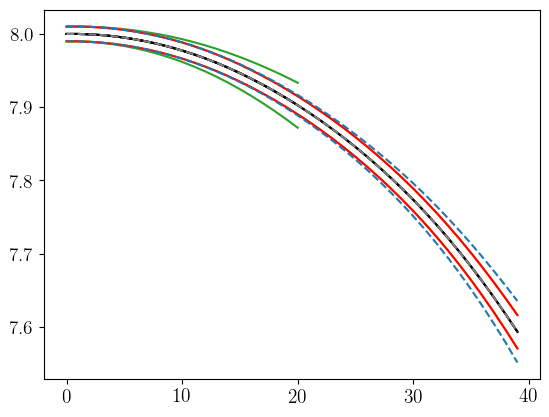

In [19]:
#compare synthesized K with initial K

traj_len = 40
state_offset = 1 # between 0 and 4

# open loop
xx, xxnom, unom_arr, _, _, _, _ = rollout_init(0.0, ix0, x0, ulim, backup_K, obs)
plt.plot(xx[:traj_len, 0+state_offset], label='init K lower', color="tab:green", linestyle='-')
plt.plot(xx[:traj_len, 5+state_offset], label='init K upper', color="tab:green", linestyle='-')
plt.plot(xxnom[:traj_len, 0+state_offset], label='init K ref', color="black", linestyle='-')

# zero K
# xx, xxnom, unom_arr = rollout(0.0, ix0, x0, 0*feedback_K, backup_K, obs)
# plt.plot(xx[:traj_len, 0+state_offset], label='NO K lower', color="tab:red", linestyle='-')
# plt.plot(xx[:traj_len, 5+state_offset], label='NO K upper', color="tab:red", linestyle='-')
# plt.plot(xxnom[:traj_len, 0+state_offset], label='OG K ref', color="black", linestyle='-')

# K from initial LQR
xx, xxnom, unom_arr = rollout(0.0, ix0, x0, feedback_K, backup_K, obs)
plt.plot(xx[:traj_len, 0+state_offset], label='LQR K lower', color="orange", linestyle='-')
plt.plot(xx[:traj_len, 5+state_offset], label='LQR K upper', color="orange", linestyle='-')
plt.plot(xxnom[:traj_len, 0+state_offset], label='OG K ref', color="black", linestyle='-')

# K from Synthesized LQR
xx, xxnom, unom_arr, _ = rollout_LQRK(0.0, ix0, x0, backup_K, ulim, obs)
plt.plot(xx[:traj_len, 0+state_offset], label='LQR K lower', color="red", linestyle='-')
plt.plot(xx[:traj_len, 5+state_offset], label='LQR K upper', color="red", linestyle='-')
plt.plot(xxnom[:traj_len, 0+state_offset], label='OG K ref', color="black", linestyle='-')

# K from synthesized
xx, xxnom, unom_arr, _ = rollout_synthK(0.0, ix0, x0, backup_K, ulim, obs)
plt.plot(xx[:traj_len, 0+state_offset], label='NEW K lower', color="tab:blue", linestyle='--')
plt.plot(xx[:traj_len, 5+state_offset], label='NEW K upper', color="tab:blue", linestyle='--')
plt.plot(xxnom[:traj_len, 0+state_offset], label='NEW K ref', color="tab:gray", linestyle='--')


print(output_K @ x_prime)
print(irx.interval(output_K) @ irx.icentpert(0., x_prime))
print(u_prime)


In [20]:
def quadplot(xpos,ypos,rot,scale):
    ts=-.5*np.arange(np.pi,3/2*np.pi,.2)+.3
    xtemp=np.cos(ts)
    ytemp=np.sin(ts)*np.cos(ts)

    xs=np.hstack((.4*xtemp-1,-1,-1,1,1,.4*xtemp+1))
    ys=np.hstack((.3*ytemp+.4,.4,0,0,.4,.3*ytemp+.4))
    xs=scale*xs
    ys=scale*ys
    rotmat=np.array([[np.cos(rot),-np.sin(rot)],[np.sin(rot),np.cos(rot)]])
    # print(xs)
    newpos=rotmat@np.vstack((xs,ys))
    xs=newpos[0,:]+xpos
    ys=newpos[1,:]+ypos
    return xs,ys

quadplot(0, 0, 0, 1)

(array([-0.88179192, -0.92053227, -0.96006663, -1.        , -1.03993337,
        -1.07946773, -1.11820808, -1.15576734, -1.        , -1.        ,
         1.        ,  1.        ,  1.11820808,  1.07946773,  1.03993337,
         1.        ,  0.96006663,  0.92053227,  0.88179192,  0.84423266]),
 array([0.31530363, 0.34158725, 0.3701996 , 0.4       , 0.4298004 ,
        0.45841275, 0.48469637, 0.50760341, 0.4       , 0.        ,
        0.        , 0.4       , 0.31530363, 0.34158725, 0.3701996 ,
        0.4       , 0.4298004 , 0.45841275, 0.48469637, 0.50760341]))

0
[-4.   8.   0.   0.   0.1]
[ 4.81 -5.  ]
0.0
0.39
0
[-4.00037143e+00  7.99498800e+00 -7.30649583e-03 -2.50598223e-01
 -1.49978182e-01]
[ 4.81026264 -4.99772341]
0.05
0.39
1
[-3.99999066  7.97735679  0.04080331 -0.50862134 -0.3997086 ]
[ 4.81128568 -4.98821054]
0.09999999999999999
0.39
2
[-3.99610379  7.94653099  0.14870322 -0.77517128 -0.64877151]
[ 5.89576821 -4.96842227]
0.15
0.39
3
[-3.98507632  7.902673    0.34843834 -1.03097404 -0.89658012]
[ 7.27575294 -4.93455885]
0.20000000000000004
0.39
4
[-3.9619849   7.84572342  0.65408387 -1.30914481 -1.14234468]
[ 8.79497572 -4.88224708]
0.25000000000000006
0.39
5
[-3.92134058  7.77382444  1.07503535 -1.6471936  -1.38505415]
[10.66253522 -4.40559791]
0.3000000000000001
0.39
6
[-3.85721311  7.68327673  1.61844253 -2.06833981 -1.48681762]
[13.02547441  1.0956067 ]
0.35000000000000014
0.39
7
[-3.76347937  7.57139838  2.27822623 -2.47236695 -1.36640722]
[14.81000013  3.34278813]
0.4000000000000002
0.6500000000000004
8
[-3.63581773  7.4415037

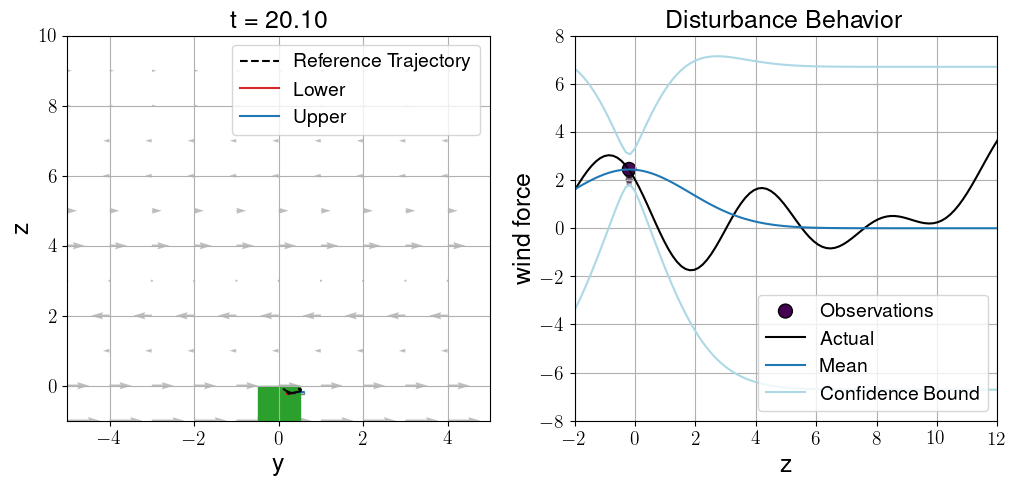

In [21]:
# RUN SIMULATION AND SAVE ANIMATION
import matplotlib.animation as animation
import matplot2tikz

from matplotlib.lines import Line2D
from matplotlib.legend import Legend

Line2D._us_dashSeq    = property(lambda self: self._dash_pattern[1])
Line2D._us_dashOffset = property(lambda self: self._dash_pattern[0])
Legend._ncol = property(lambda self: self._ncols)


def u_applied(x, xref, uref, K_feedback):
    ubackup = (K_feedback @ (xref - x)) + uref
    unomt = np.array([np.minimum(np.maximum(ubackup[0], ulim.lower[0]), ulim.upper[0]),
            np.minimum(np.maximum(ubackup[1], ulim.lower[1]), ulim.upper[1])])
    return unomt


current_state = x0
current_int = irx.icentpert(current_state, x0_buf)
current_time = 0.0
traj_idx = 0
sim_dt = 0.05
sim_length = 20.0
thresh = 0.7
synthesize_controller = 0 #0 = Don't, 1 = LMI, 2 = LQR
sim_K = feedback_K

collection_time_arr = []


# setup disturbance behavior
np.random.seed(0)
actual_disturbance_GP_f = GPR(jnp.array([[-2,-0.66005468347438],
                                       [0,1.71910828159421],
                                       [2,-2.73909534657961],
                                       [4,3.76474225408493],
                                       [6,3.65733558594356],
                                       [8,-0.116994810217270],
                                       [10,2.40224375111040],
                                       [12,-2.86490929098228],
                                       ]), 
                                       sigma_f = 5.0, 
                                       l=2.0, 
                                       sigma_n = 0.01
                                       )
actual_disturbance_GP_g = GPR(jnp.array([[-2,2.80494480741922],
                                       [0,-1.65967058757266],
                                       [2,-2.21529178685802],
                                       [4,-2.41828274757721],
                                       [6,-0.976879063072681],
                                       [8,-2.89172701466510],
                                       [10,-3.91337304908981],
                                       [12,-3.33944976072828],
                                       ]),
                                        sigma_f = 5.0,
                                        l=2.0,
                                        sigma_n = 0.01,
                                        )
dist_f_time = 0.0
dist_update_mag = 1.5

def actual_disturbance (t, x, epsilon=0.25) :
    t_leftover = t % 1.0
    cur_val = actual_disturbance_GP_f.mean(jnp.array([x[1]])).reshape(-1)
    next_val = jnp.sqrt(1-epsilon)*actual_disturbance_GP_f.mean(jnp.array([x[1]])).reshape(-1) + jnp.sqrt(epsilon)*actual_disturbance_GP_g.mean(jnp.array([x[1]])).reshape(-1)
    return (1.0 - t_leftover)*cur_val + t_leftover*next_val

obs = jnp.array([[0., x0[1], actual_disturbance(0.0, x0)[0]], 
                    [0., x0[1], actual_disturbance(0.0, x0)[0]], 
                    [0., x0[1], actual_disturbance(0.0, x0)[0]],
                    [0., x0[1], actual_disturbance(0.0, x0)[0]],
                    [0., x0[1], actual_disturbance(0.0, x0)[0]],
                    [0., x0[1], actual_disturbance(0.0, x0)[0]],
                    [0., x0[1], actual_disturbance(0.0, x0)[0]],
                    [0., x0[1], actual_disturbance(0.0, x0)[0]],
                    [0., x0[1], actual_disturbance(0.0, x0)[0]]])

if synthesize_controller == 1:
    xx, xxnom, unom_arr, sim_K = rollout_synthK(current_time, current_int, current_state, backup_K, ulim, obs)
elif synthesize_controller == 2:
    xx, xxnom, unom_arr, sim_K = rollout_LQRK(current_time, current_int, current_state, backup_K, ulim, obs)
else:
    xx, xxnom, unom_arr = rollout(current_time, current_int, current_state, sim_K, backup_K, obs)
t_arr = np.arange(current_time, current_time + T, dt)
t_index = collection_id(xxnom, xx, thresh)
collection_time = t_arr[t_index]
collection_time_arr.append(collection_time - current_time)
applied_input = u_applied(current_state, xxnom[traj_idx, :], unom_arr[traj_idx, :], sim_K)
flight_path = np.array([x0])


PLOT_OBS = True
SAVE_TIKZ = False # tikz export is not working in the document somehow so don't use this
SAVE_PDF = False

# PLOTTING
if PLOT_OBS:
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 5))
else:
    fig, ax = plt.subplots()

FONTSIZE = 18
LINEWIDTH = 1.5
QUADSIZE = 0.15
OBSSIZE = 100
SCATTERORDER = -1
if SAVE_PDF:
    FONTSIZE = 24
    LINEWIDTH = 3
    QUADSIZE = 0.25
    OBSSIZE = 200
    SCATTERORDER = 10
    

# # wind disturbance
arrow_points = np.mgrid[-5:5, -1:10].reshape(2, -1).T
arrow_dirs = arrow_points*0.0
for a in range(arrow_points.shape[0]):
    arrow_dirs[a, :] = [actual_disturbance(0.0, np.array([arrow_points[a, 0], arrow_points[a, 1], 0.0, 0.0, 0.0]))[0], 0.0]
wind_arrows = ax.quiver(arrow_points[:, 0], arrow_points[:, 1], arrow_dirs[:, 0], arrow_dirs[:, 1], color='tab:gray', alpha=0.5)

# mixed monotonicity tube
# t_index = int(t_star/dt)
# t_index_plot = -2 if SAVE_PDF else t_index + 1 # plot up to deviation
t_index_plot = t_index
nominal = ax.plot(xxnom[:,0], xxnom[:,1], label='Reference Trajectory', linestyle="dashed", color="black", linewidth=LINEWIDTH)[0]
lower = ax.plot(xx[:t_index_plot+1,0], xx[:t_index_plot+1,1], label='Lower', color="tab:red", linewidth=LINEWIDTH)[0]
upper = ax.plot(xx[:t_index_plot+1,5], xx[:t_index_plot+1,6], label='Upper', color = "tab:blue", linewidth=LINEWIDTH)[0]

# actual = ax.plot(xa[:t_index,0], xa[:t_index,1], label='Actual', linestyle="dashed")[0]
# flight = ax.plot(x0[0], x0[1], label='Flight Trajectory', color='black')[0]

start_rect = Rectangle((xx[0,0], xx[0,1]), xx[0,5] - xx[0,0], xx[0,6] - xx[0,1], linewidth=1, edgecolor='tab:gray', facecolor='none')
start_patch = ax.add_patch(start_rect)
# end_rect = Rectangle((xx[-1,0], xx[-1,1]), xx[-1,5] - xx[-1,0], xx[-1,6] - xx[-1,1], linewidth=1, edgecolor='tab:gray', facecolor='none', linestyle="dashed")
end_rect = Rectangle((xx[t_index_plot,0], xx[t_index_plot+1,1]), xx[t_index_plot+1,5] - xx[t_index_plot+1,0], xx[t_index_plot+1,6] - xx[t_index_plot+1,1], linewidth=1, edgecolor='tab:gray', facecolor='none')
end_patch = ax.add_patch(end_rect)
landing_rect = Rectangle((-0.5, -1.0), 1.0, 1.0, linewidth=1, edgecolor='tab:green', facecolor='tab:green')
ax.add_patch(landing_rect)
quad_x, quad_y = quadplot(x0[0], x0[1], x0[4], QUADSIZE)
quad = ax.plot(quad_x, quad_y, color='black', linewidth=LINEWIDTH)[0]

plt.axes(ax)
plt.xlabel('y', fontsize=FONTSIZE)
plt.ylabel('z', fontsize=FONTSIZE)
titletime = plt.title('t = %1.2f' % current_time, fontsize=FONTSIZE)
if not SAVE_PDF: plt.legend(loc ='upper right', fontsize=FONTSIZE - 4) 
if not SAVE_PDF: plt.grid()
# plt.gca().set_aspect('equal')
plt.gca().set_xlim([-5, 5])
plt.gca().set_ylim([-1, 10])

if PLOT_OBS:
    gp_query_points = np.array([[0.0, p] for p in np.linspace(-2, 12, 100)])
    plotTVGP = TVGPR(obs, sigma_f = 5.0, l=2.0, sigma_n = 0.01, epsilon = 0.25)
    mean_pts = jnp.array([plotTVGP.mean(gpqp) for gpqp in gp_query_points]).reshape(-1)
    actual_pts = jnp.array([actual_disturbance(gpqp[0], jnp.array([0., gpqp[1], 0., 0., 0.]))[0] for gpqp in gp_query_points]).reshape(-1)
    sig_pts = 3*jnp.array([jnp.sqrt(plotTVGP.variance(gpqp)) for gpqp in gp_query_points]).reshape(-1)
    
    observations = ax2.scatter(obs[:, 1], obs[:, 2], label='Observations', c=obs[:, 0], cmap='viridis', s=OBSSIZE, edgecolors='black', zorder=SCATTERORDER)
    actual = ax2.plot(gp_query_points[:, 1], actual_pts, label='Actual', color='black', linewidth=LINEWIDTH)[0]
    mean = ax2.plot(gp_query_points[:, 1], mean_pts, label='Mean', color='tab:blue', linewidth=LINEWIDTH)[0]
    upper_conf = ax2.plot(gp_query_points[:, 1], mean_pts + sig_pts, label='Confidence Bound', color='lightblue', linewidth=LINEWIDTH)[0]
    lower_conf = ax2.plot(gp_query_points[:, 1], mean_pts - sig_pts, color='lightblue', linewidth=LINEWIDTH)[0]


    plt.axes(ax2)
    plt.xlabel('z', fontsize=FONTSIZE)
    plt.ylabel('wind force', fontsize=FONTSIZE)
    plt.title('Disturbance Behavior', fontsize=FONTSIZE)
    if not SAVE_PDF: plt.legend(loc ='lower right', fontsize=FONTSIZE - 4) 
    plt.grid()
    # plt.gca().set_aspect('equal')
    plt.gca().set_xlim([-2, 12])
    plt.gca().set_ylim([-8, 8])

if SAVE_TIKZ:
    plt.show()
    print("Saving tikz figure")
    matplot2tikz.clean_figure()
    filename = "tex/landing_sim_tvgp_withobs_ogdyn_simple_%1.2f.tex" % current_time
    matplot2tikz.save(filename, figure=fig)

if SAVE_PDF:
    # plt.show()
    print("Saving pdf figure")
    filename = "pdf/rta_nosynth_%1.2f.pdf" % current_time
    plt.savefig(filename, format="pdf", bbox_inches="tight")


def update(frame):
    # apply input, update state/time
    global current_state, applied_input, current_time, flight_path, collection_time, collection_time_arr, traj_idx, t_index, t_index_plot, obs, xxnom, xx, unom_arr, arrow_points, wind_arrows, actual_disturbance_GP_f, actual_disturbance_GP_g, dist_f_time, plotTVGP, mean, actual, PLOT_OBS, SAVE_TIKZ, observations, upper, lower, dist_update_mag, OBSSIZE, sim_K
    print(frame)
    print(current_state)
    print(applied_input)
    print(current_time)
    print(collection_time)

    for i in range(int(sim_dt/dt)):
        # while current_time < current_time + sim_dt:
        current_state = current_state + dt * sys.f_np(current_time, current_state, applied_input, actual_disturbance(current_time, current_state))
        flight_path = np.vstack((flight_path, current_state))
        current_int = irx.icentpert(current_state, x0_buf)
        current_time = current_time + dt
        traj_idx += 1
        
        # if current_time >= collection_time, collect new observation and recompute
        if current_time >= collection_time:
            obs = jnp.vstack((obs[1:, :], jnp.array([[current_time, current_state[1], actual_disturbance(current_time, current_state)[0]]])))
            if PLOT_OBS: plotTVGP = TVGPR(obs, sigma_f = 5.0, l=2.0, sigma_n = 0.01, epsilon = 0.25)
            # print(obs)
            if synthesize_controller == 1:
                xx, xxnom, unom_arr, sim_K = rollout_synthK(current_time, current_int, current_state, backup_K, ulim, obs)
            elif synthesize_controller == 2:
                xx, xxnom, unom_arr, sim_K = rollout_LQRK(current_time, current_int, current_state, backup_K, ulim, obs)
            else:
                xx, xxnom, unom_arr = rollout(current_time, current_int, current_state, sim_K, backup_K, obs)

            t_arr = np.arange(current_time, current_time + T, dt)
            t_index = collection_id(xxnom, xx, thresh)
            # t_index_plot = -2 if SAVE_PDF else t_index + 10
            t_index_plot = t_index + 10
            collection_time = t_arr[t_index]
            collection_time_arr.append(collection_time - current_time)    
            
            traj_idx = 0

        # if it's been 1 second, crete next portion of disturbance behavior
        if current_time >= dist_f_time + 1.0:
            dist_f_time = jnp.floor(current_time)
            actual_disturbance_GP_f = GPR(jnp.array([[-2, actual_disturbance(0.99, [0, -2])[0]],
                                       [0,actual_disturbance(0.99, [0, 0])[0]],
                                       [2,actual_disturbance(0.99, [0, 2])[0]],
                                       [4,actual_disturbance(0.99, [0, 4])[0]],
                                       [6,actual_disturbance(0.99, [0, 6])[0]],
                                       [8,actual_disturbance(0.99, [0, 8])[0]],
                                       [10,actual_disturbance(0.99, [0, 10])[0]],
                                       [12,actual_disturbance(0.99, [0, 12])[0]],
                                       ]), 
                                       sigma_f = 5.0, 
                                       l=2.0, 
                                       sigma_n = 0.01
                                       )
            actual_disturbance_GP_g = GPR(jnp.array([[-2, np.random.normal(scale=dist_update_mag)],
                                        [0,np.random.normal(scale=dist_update_mag)],
                                        [2,np.random.normal(scale=dist_update_mag)],
                                        [4,np.random.normal(scale=dist_update_mag)],
                                        [6,np.random.normal(scale=dist_update_mag)],
                                        [8,np.random.normal(scale=dist_update_mag)],
                                        [10,np.random.normal(scale=dist_update_mag)],
                                        [12,np.random.normal(scale=dist_update_mag)],
                                        ]),
                                        sigma_f = 5.0,
                                        l=2.0,
                                        sigma_n = 0.01,
                                        )
            

        applied_input = u_applied(current_state, xxnom[traj_idx, :], unom_arr[traj_idx, :], sim_K)
    # t_index = -1
    
    arrow_dirs = arrow_points*0.0
    for a in range(arrow_points.shape[0]):
        arrow_dirs[a, :] = [actual_disturbance(current_time, np.array([arrow_points[a, 0], arrow_points[a, 1], 0.0, 0.0, 0.0]))[0], 0.0]
    wind_arrows.set_UVC(arrow_dirs[:, 0], arrow_dirs[:, 1])


    nominal.set_data(xxnom[:,0], xxnom[:,1])
    lower.set_data(xx[:t_index_plot+1,0], xx[:t_index_plot+1,1])
    upper.set_data(xx[:t_index_plot+1,5], xx[:t_index_plot+1,6])
    
    quad_x, quad_y = quadplot(current_state[0], current_state[1], current_state[4], QUADSIZE)
    quad.set_data(quad_x, quad_y)
    # actual.set_data(xa[:t_index,0], xa[:t_index,1])
    # flight.set_data(flight_path[:,0], flight_path[:,1])
    start_patch.set_xy((xx[0,0], xx[0,1]))
    start_patch.set_width(xx[0,5] - xx[0,0])
    start_patch.set_height(xx[0,6] - xx[0,1])
    end_patch.set_xy((xx[t_index_plot+1,0], xx[t_index_plot+1,1]))
    end_patch.set_width(xx[t_index_plot+1,5] - xx[t_index_plot+1,0])
    end_patch.set_height(xx[t_index_plot+1,6] - xx[t_index_plot+1,1])
    
    titletime.set_text('t = %1.2f' % current_time)

    if PLOT_OBS:
        gp_query_points[:, 0] = current_time
        mean_pts = jnp.array([plotTVGP.mean(gpqp) for gpqp in gp_query_points]).reshape(-1)
        actual_pts = jnp.array([actual_disturbance(gpqp[0], jnp.array([0., gpqp[1], 0., 0., 0.]))[0] for gpqp in gp_query_points]).reshape(-1)
        sig_pts = 3*jnp.array([jnp.sqrt(plotTVGP.variance(gpqp)) for gpqp in gp_query_points]).reshape(-1)
        
        
        actual.set_data(gp_query_points[:, 1], actual_pts)
        mean.set_data(gp_query_points[:, 1], mean_pts)
        upper_conf.set_data(gp_query_points[:, 1], mean_pts + sig_pts)
        lower_conf.set_data(gp_query_points[:, 1], mean_pts - sig_pts)
        observations.set_offsets(obs[:, 1:])
        observations.set_sizes(OBSSIZE*jnp.exp(2*(obs[:, 0] - current_time)))
        if not SAVE_PDF: observations.set_alpha(jnp.exp(1.0*(obs[:, 0] - current_time)))

    if SAVE_TIKZ:
        if (frame+2) % 20 == 0:
            plt.show()
            print("Saving tikz figure")
            matplot2tikz.clean_figure()
            filename = "tex/landing_sim_tvgp_withobs_ogdyn_simple_%1.2f.tex" % current_time
            matplot2tikz.save(filename, figure=fig, axis_width=r'\figurewidth', axis_height=r'\figureheight', extra_axis_parameters=['legend style={font=\tiny}'])
    
    if SAVE_PDF:
        if (frame+2) % 20 == 0:
            # plt.show()
            print("Saving pdf figure")
            filename = "pdf/rta_nosynth_%1.2f.pdf" % current_time
            plt.savefig(filename, format="pdf", bbox_inches="tight")
    

    return (nominal, lower, upper, quad, start_patch, end_patch, titletime)

ani = animation.FuncAnimation(fig=fig, func=update, frames=int(sim_length/sim_dt), interval=int(sim_dt*1000))
ani.save(filename="test_workingsigma.gif", writer="pillow")

In [22]:
print(np.max(collection_time_arr))
print(np.mean(collection_time_arr))

0.4
0.38452830188679954


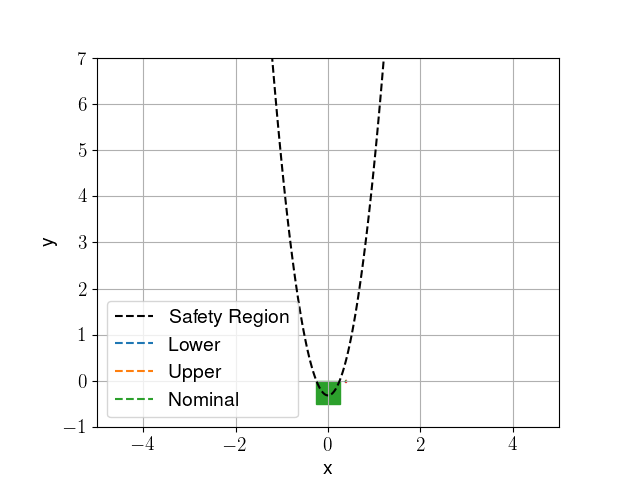

In [ ]:
%matplotlib ipympl

import shapely.ops as so

# plot trajectories
fig, ax = plt.subplots()

cbf_x = np.linspace(-1.5, 1.5, 100)
cbf_y = 5*(cbf_x**2 - 0.0625)
ax.plot(cbf_x, cbf_y, label='Safety Region', linestyle="dashed", color='black')

# mixed monotonicity tube
ax.plot(xx[:,0], xx[:,1], label='Lower', linestyle="dashed")
ax.plot(xx[:,5], xx[:,6], label='Upper', linestyle="dashed")
ax.plot(xxnom[:,0], xxnom[:,1], label='Nominal', linestyle="dashed")

start_rect = Rectangle((xx[0,0], xx[0,1]), xx[0,5] - xx[0,0], xx[0,6] - xx[0,1], linewidth=1, edgecolor='tab:gray', facecolor='none')
ax.add_patch(start_rect)
end_rect = Rectangle((xx[-1,0], xx[-1,1]), xx[-1,5] - xx[-1,0], xx[-1,6] - xx[-1,1], linewidth=1, edgecolor='tab:red', facecolor='none')
ax.add_patch(end_rect)
landing_rect = Rectangle((-0.25, -0.5), 0.5, 0.5, linewidth=1, edgecolor='tab:green', facecolor='tab:green')
ax.add_patch(landing_rect)

# irx.utils.draw_iarrays(ax, [irx.ut2i(xxi) for xxi in xx], ec='tab:red')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.gca().set_aspect('equal')
plt.gca().set_xlim([-5, 5])
plt.gca().set_ylim([-1, 7])
plt.show()




NameError: name 'xa' is not defined

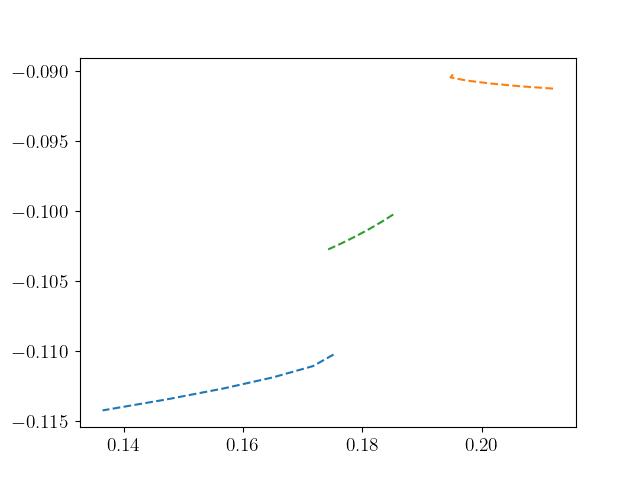

In [ ]:
# plot trajectories
fig, ax = plt.subplots()

# mixed monotonicity tube
plt.plot(xx[:,2], xx[:,3], label='Lower', linestyle="dashed")
plt.plot(xx[:,7], xx[:,8], label='Upper', linestyle="dashed")
plt.plot(xxnom[:,2], xxnom[:,3], label='Nominal', linestyle="dashed")
plt.plot(xa[:,2], xa[:,3], label='Actual')
start_rect = Rectangle((xx[0,2], xx[0,3]), xx[0,7] - xx[0,2], xx[0,8] - xx[0,3], linewidth=1, edgecolor='tab:gray', facecolor='none')
ax.add_patch(start_rect)
end_rect = Rectangle((xx[-1,2], xx[-1,3]), xx[-1,7] - xx[-1,2], xx[-1,8] - xx[-1,3], linewidth=1, edgecolor='tab:red', facecolor='none')
ax.add_patch(end_rect)

# irx.utils.draw_iarrays(ax, [irx.ut2i(xxi) for xxi in xx], 2, 3, ec='tab:red')

plt.xlabel('vx')
plt.ylabel('vy')
plt.legend()
plt.show()




In [ ]:
# plot trajectories
fig, ax = plt.subplots()

# mixed monotonicity tube
plt.plot(xx[:,2], xx[:,4], label='Lower', linestyle="dashed")
plt.plot(xx[:,7], xx[:,9], label='Upper', linestyle="dashed")
plt.plot(xxnom[:,2], xxnom[:,4], label='Nominal', linestyle="dashed")
plt.plot(xa[:,2], xa[:,4], label='Actual')
start_rect = Rectangle((xx[0,2], xx[0,4]), xx[0,7] - xx[0,2], xx[0,9] - xx[0,4], linewidth=1, edgecolor='tab:gray', facecolor='none')
ax.add_patch(start_rect)
end_rect = Rectangle((xx[-1,2], xx[-1,4]), xx[-1,7] - xx[-1,2], xx[-1,9] - xx[-1,4], linewidth=1, edgecolor='tab:red', facecolor='none')
ax.add_patch(end_rect)

# irx.utils.draw_iarrays(ax, [irx.ut2i(xxi) for xxi in xx], 2, 4, ec='tab:red')

plt.xlabel('vx')
plt.ylabel('theta')
plt.legend()
plt.show()


